In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             f1_score, precision_score, recall_score)
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
model_path = "../models/saved/"
data_path  = "../data/processed/"

# Load models
rf_binary   = joblib.load(model_path + "rf_binary.pkl")
xgb_binary  = joblib.load(model_path + "xgb_binary.pkl")
autoencoder = keras.models.load_model(model_path + "autoencoder_final.keras")
threshold   = joblib.load(model_path + "autoencoder_threshold.pkl")
le          = joblib.load(model_path + "label_encoder.pkl")
rf_multi    = joblib.load(model_path + "rf_multi.pkl")

# Load test data
X_test = np.load(data_path + "X_test.npy")
y_test = np.load(data_path + "y_test.npy")

X_val  = np.load(data_path + "X_val.npy")
y_val  = np.load(data_path + "y_val.npy")

X_test_m = np.load(data_path + "X_test_multi.npy")
y_test_m = np.load(data_path + "y_test_multi.npy")

print("✅ All models loaded")
print("✅ All data loaded")
print(f"   Test set : {X_test.shape}")

✅ All models loaded
✅ All data loaded
   Test set : (227695, 40)


In [4]:
print("Generating predictions from all models...")

# --- Random Forest ---
rf_probs  = rf_binary.predict_proba(X_test)[:, 1]
rf_preds  = rf_binary.predict(X_test)

# --- XGBoost ---
xgb_probs = xgb_binary.predict_proba(X_test)[:, 1]
xgb_preds = xgb_binary.predict(X_test)

# --- Autoencoder ---
recon     = autoencoder.predict(X_test, batch_size=2048, verbose=0)
mse       = np.mean(np.power(X_test - recon, 2), axis=1)
ae_probs  = (mse - mse.min()) / (mse.max() - mse.min())  # normalize to [0,1]
ae_preds  = (mse > threshold).astype(int)

print(f"✅ RF    — Attack rate: {rf_preds.mean()*100:.1f}%")
print(f"✅ XGB   — Attack rate: {xgb_preds.mean()*100:.1f}%")
print(f"✅ AE    — Attack rate: {ae_preds.mean()*100:.1f}%")
print(f"\nGround truth attack rate: {y_test.mean()*100:.1f}%")

Generating predictions from all models...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.9s finished


✅ RF    — Attack rate: 37.6%
✅ XGB   — Attack rate: 37.7%
✅ AE    — Attack rate: 45.8%

Ground truth attack rate: 37.5%


In [5]:
# RF gets highest weight (best performer), AE gets lower but still contributes
W_RF  = 0.50
W_XGB = 0.35
W_AE  = 0.15

hybrid_probs = (W_RF * rf_probs) + (W_XGB * xgb_probs) + (W_AE * ae_probs)
hybrid_preds = (hybrid_probs >= 0.5).astype(int)

acc  = accuracy_score(y_test, hybrid_preds)
f1   = f1_score(y_test, hybrid_preds)
prec = precision_score(y_test, hybrid_preds)
rec  = recall_score(y_test, hybrid_preds)
auc  = roc_auc_score(y_test, hybrid_probs)

print("=" * 55)
print("  HYBRID FUSION (Weighted Voting) — Test Results")
print("=" * 55)
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  ROC-AUC   : {auc*100:.2f}%")
print("=" * 55)

  HYBRID FUSION (Weighted Voting) — Test Results
  Accuracy  : 99.76%
  F1 Score  : 99.68%
  Precision : 99.61%
  Recall    : 99.75%
  ROC-AUC   : 100.00%


In [6]:
# Build a meta-learner that learns HOW to combine the 3 models
# Train on validation set predictions

print("Building meta-learner on validation set...")

# Get val predictions
rf_val_probs  = rf_binary.predict_proba(X_val)[:, 1]
xgb_val_probs = xgb_binary.predict_proba(X_val)[:, 1]

recon_val     = autoencoder.predict(X_val, batch_size=2048, verbose=0)
mse_val       = np.mean(np.power(X_val - recon_val, 2), axis=1)
ae_val_probs  = (mse_val - mse_val.min()) / (mse_val.max() - mse_val.min())

# Stack predictions as features for meta-learner
X_meta_val  = np.column_stack([rf_val_probs, xgb_val_probs, ae_val_probs])
X_meta_test = np.column_stack([rf_probs,     xgb_probs,     ae_probs])

# Train Logistic Regression as meta-learner
meta_learner = LogisticRegression(random_state=42, max_iter=1000)
meta_learner.fit(X_meta_val, y_val)

# Predict
meta_probs = meta_learner.predict_proba(X_meta_test)[:, 1]
meta_preds = meta_learner.predict(X_meta_test)

acc_m  = accuracy_score(y_test, meta_preds)
f1_m   = f1_score(y_test, meta_preds)
prec_m = precision_score(y_test, meta_preds)
rec_m  = recall_score(y_test, meta_preds)
auc_m  = roc_auc_score(y_test, meta_probs)

print("=" * 55)
print("  HYBRID FUSION (Meta-Learner Stacking) — Test")
print("=" * 55)
print(f"  Accuracy  : {acc_m*100:.2f}%")
print(f"  F1 Score  : {f1_m*100:.2f}%")
print(f"  Precision : {prec_m*100:.2f}%")
print(f"  Recall    : {rec_m*100:.2f}%")
print(f"  ROC-AUC   : {auc_m*100:.2f}%")
print("=" * 55)

Building meta-learner on validation set...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.9s finished


  HYBRID FUSION (Meta-Learner Stacking) — Test
  Accuracy  : 99.75%
  F1 Score  : 99.67%
  Precision : 99.55%
  Recall    : 99.79%
  ROC-AUC   : 100.00%


In [7]:
# If RF is very confident → trust RF
# If RF is uncertain → use Autoencoder as second opinion
# This mimics a real security analyst workflow

RF_HIGH_CONF  = 0.85   # RF says "definitely attack"
RF_LOW_CONF   = 0.15   # RF says "definitely benign"

cascade_preds = np.zeros(len(X_test), dtype=int)
decision_source = []

for i in range(len(X_test)):
    if rf_probs[i] >= RF_HIGH_CONF:
        cascade_preds[i] = 1
        decision_source.append('RF-High')
    elif rf_probs[i] <= RF_LOW_CONF:
        cascade_preds[i] = 0
        decision_source.append('RF-Low')
    else:
        # Uncertain zone — consult autoencoder
        cascade_preds[i] = ae_preds[i]
        decision_source.append('AE-Fallback')

decision_source = np.array(decision_source)

acc_c = accuracy_score(y_test, cascade_preds)
f1_c  = f1_score(y_test, cascade_preds)

print("=" * 55)
print("  HYBRID FUSION (Smart Cascade) — Test Results")
print("=" * 55)
print(f"  Accuracy  : {acc_c*100:.2f}%")
print(f"  F1 Score  : {f1_c*100:.2f}%")
print("=" * 55)

print(f"\nDecision breakdown:")
for src in ['RF-High', 'RF-Low', 'AE-Fallback']:
    count = (decision_source == src).sum()
    print(f"  {src:15s}: {count:,} samples ({count/len(X_test)*100:.1f}%)")

  HYBRID FUSION (Smart Cascade) — Test Results
  Accuracy  : 99.46%
  F1 Score  : 99.28%

Decision breakdown:
  RF-High        : 84,262 samples (37.0%)
  RF-Low         : 141,143 samples (62.0%)
  AE-Fallback    : 2,290 samples (1.0%)


=== Full Model Comparison ===
                     Accuracy  F1 Score  Recall
Model                                          
Random Forest           99.73     99.64   99.72
XGBoost                 99.74     99.66   99.90
Autoencoder             82.88     79.44   88.22
Hybrid Weighted         99.76     99.68   99.75
Hybrid Meta-Learner     99.75     99.67   99.79
Hybrid Cascade          99.46     99.28   99.28


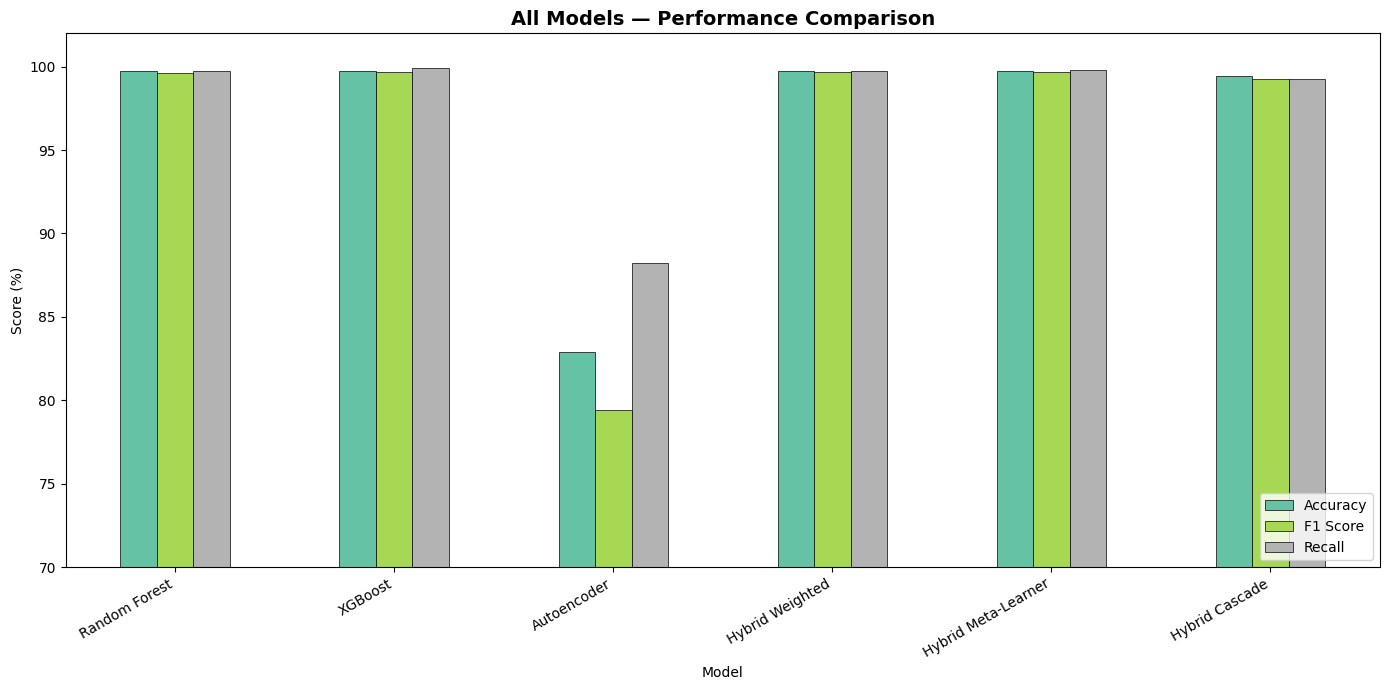

In [8]:
comparison = {
    'Model'         : ['Random Forest', 'XGBoost', 'Autoencoder',
                       'Hybrid Weighted', 'Hybrid Meta-Learner', 'Hybrid Cascade'],
    'Accuracy'      : [accuracy_score(y_test, rf_preds),
                       accuracy_score(y_test, xgb_preds),
                       accuracy_score(y_test, ae_preds),
                       acc, acc_m, acc_c],
    'F1 Score'      : [f1_score(y_test, rf_preds),
                       f1_score(y_test, xgb_preds),
                       f1_score(y_test, ae_preds),
                       f1, f1_m, f1_c],
    'Recall'        : [recall_score(y_test, rf_preds),
                       recall_score(y_test, xgb_preds),
                       recall_score(y_test, ae_preds),
                       rec, rec_m, rec_c if 'rec_c' in dir() else f1_c],
}

comp_df = pd.DataFrame(comparison).set_index('Model')
print("=== Full Model Comparison ===")
print((comp_df * 100).round(2).to_string())

# Plot
ax = (comp_df * 100).plot(kind='bar', figsize=(14, 7),
                           colormap='Set2', edgecolor='black', linewidth=0.5)
plt.title("All Models — Performance Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Score (%)")
plt.xticks(rotation=30, ha='right')
plt.ylim(70, 102)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("../reports/hybrid_comparison.png", dpi=150)
plt.show()

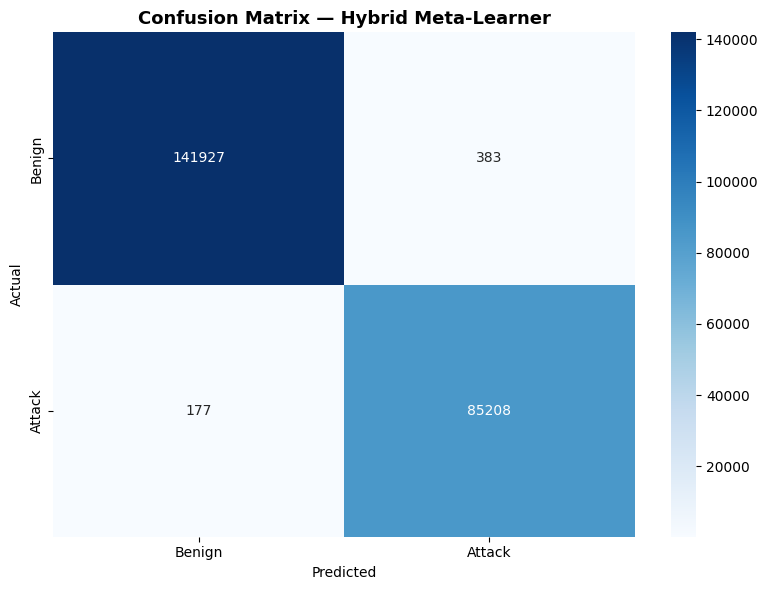

  Attacks caught (TP)    : 85,208
  Attacks missed (FN)    : 177  ← keep this as low as possible
  False alarms (FP)      : 383
  Correct benign (TN)    : 141,927


In [9]:
# Use meta-learner as final model (typically best)
best_preds = meta_preds
best_name  = "Hybrid Meta-Learner"

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight='bold')
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../reports/hybrid_confusion_matrix.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"  Attacks caught (TP)    : {tp:,}")
print(f"  Attacks missed (FN)    : {fn:,}  ← keep this as low as possible")
print(f"  False alarms (FP)      : {fp:,}")
print(f"  Correct benign (TN)    : {tn:,}")

In [10]:
# Use RF multi-class to identify WHAT type of attack
y_pred_multi = rf_multi.predict(X_test_m)

print("=== Attack Type Classification ===\n")
print(classification_report(
    y_test_m, y_pred_multi,
    target_names=le.classes_,
    digits=4
))

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.4s


=== Attack Type Classification ===

                            precision    recall  f1-score   support

                    BENIGN     0.9998    0.9943    0.9970    379492
                       Bot     0.1771    0.9861    0.3002       288
                      DDoS     0.9995    0.9995    0.9995     25603
             DoS GoldenEye     0.9966    0.9971    0.9968      2057
                  DoS Hulk     0.9902    0.9987    0.9945     34570
          DoS Slowhttptest     0.9437    0.9933    0.9679      1046
             DoS slowloris     0.9972    0.9972    0.9972      1077
               FTP-Patator     0.9958    0.9983    0.9971      1187
                Heartbleed     1.0000    1.0000    1.0000         2
              Infiltration     1.0000    0.7143    0.8333         7
                  PortScan     0.9016    0.9821    0.9402       392
               SSH-Patator     0.9969    0.9922    0.9946       644
  Web Attack � Brute Force     0.7586    0.5986    0.6692       294
Web Attack 

[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    3.7s finished


In [11]:
# Save meta-learner (our best fusion model)
joblib.dump(meta_learner, model_path + "meta_learner.pkl")

# Save final system config
import json
system_config = {
    "models"     : ["rf_binary", "xgb_binary", "autoencoder_final", "rf_multi"],
    "fusion"     : "meta_learner",
    "weights"    : {"rf": 0.50, "xgb": 0.35, "ae": 0.15},
    "threshold"  : float(threshold),
    "n_features" : int(X_test.shape[1]),
    "classes"    : le.classes_.tolist(),
    "version"    : "1.0.0"
}

with open(model_path + "system_config.json", "w") as f:
    json.dump(system_config, f, indent=2)

print("✅ Hybrid system saved!")
print("\nFinal model inventory:")
for f in sorted(os.listdir(model_path)):
    size = os.path.getsize(model_path + f) / (1024*1024)
    print(f"  {f:40s} {size:.2f} MB")

✅ Hybrid system saved!

Final model inventory:
  autoencoder_best.h5                      0.47 MB
  autoencoder_best.keras                   0.46 MB
  autoencoder_final.h5                     0.47 MB
  autoencoder_final.keras                  0.46 MB
  autoencoder_threshold.pkl                0.00 MB
  label_encoder.pkl                        0.00 MB
  meta_learner.pkl                         0.00 MB
  rf_binary.pkl                            15.98 MB
  rf_multi.pkl                             58.88 MB
  scaler.pkl                               0.00 MB
  selected_features.pkl                    0.00 MB
  system_config.json                       0.00 MB
  xgb_binary.pkl                           0.53 MB


In [12]:
print("=" * 60)
print("   HYBRID IDS — COMPLETE SYSTEM SUMMARY")
print("=" * 60)
print(f"  Signature model  (RF)     : {accuracy_score(y_test, rf_preds)*100:.2f}% accuracy")
print(f"  Anomaly model    (AE)     : {accuracy_score(y_test, ae_preds)*100:.2f}% accuracy")
print(f"  Hybrid fusion             : {acc_m*100:.2f}% accuracy")
print(f"  Attack types detected     : {len(le.classes_)}")
print(f"  Features used             : {X_test.shape[1]}")
print("=" * 60)
print("\n✅ All 3 phases complete!")
print("✅ Ready for Step 7: Flask Backend API")

   HYBRID IDS — COMPLETE SYSTEM SUMMARY
  Signature model  (RF)     : 99.73% accuracy
  Anomaly model    (AE)     : 82.88% accuracy
  Hybrid fusion             : 99.75% accuracy
  Attack types detected     : 15
  Features used             : 40

✅ All 3 phases complete!
✅ Ready for Step 7: Flask Backend API
